In [65]:
import networkx as nx
import pandas as pd
import random
import matplotlib.pyplot as plt
from community import community_louvain

random.seed(42)

In [66]:

# Grafo Completo do Facebook com todos os 4039 nós
Grafo_Full = nx.read_edgelist("facebook_combined.txt", create_using=nx.Graph())

# Faz a extração de 200 nós aleatórios do grafo completo
all_nodes = list(Grafo_Full.nodes())
sampled_nodes = random.sample(all_nodes, 200)

# Criar um subgrafo com os nós amostrados e todas as arestas originais entre eles

G = Grafo_Full.subgraph(sampled_nodes).copy()

print(f"Grau de amostragem: {G.number_of_nodes()} nós e {G.number_of_edges()} arestas")

# Teste de aleatoriedade (verificar se os nós mudam sem seed ou se mantêm com seed)
print(f"Amostra de nós: {list(G.nodes())[:5]}")

Grau de amostragem: 200 nós e 210 arestas
Amostra de nós: ['2044', '2342', '2879', '2722', '3378']


In [67]:
# Dicionários para armazenar as métricas

metricas = {
    "Grau": nx.degree_centrality(G),
    "Intermediação": nx.betweenness_centrality(G),
    "Proximidade": nx.closeness_centrality(G),
    "Autovetor": nx.eigenvector_centrality(G, max_iter=1000),
}


# Converter para Dataframe para facilitar a análise no mini-relatório

df_metricas = pd.DataFrame(metricas)

print("Top 5 nós por Grau de Centralidade:")
print(df_metricas.sort_values(by="Grau", ascending=False).head())



Top 5 nós por Grau de Centralidade:
          Grau  Intermediação  Proximidade  Autovetor
1447  0.055276       0.001565     0.067002   0.348484
1598  0.050251       0.001159     0.064840   0.351062
1610  0.045226       0.000957     0.060911   0.335305
3078  0.040201       0.000552     0.040536   0.000270
1467  0.040201       0.001380     0.059119   0.244608


In [68]:
# Detecção de comunidade usando o algoritmo de Louvain

particao = community_louvain.best_partition(G)
nx.set_node_attributes(G, particao, "comunidade")
print("\nNúmero de comunidades detectadas:", len(set(particao.values())))


Número de comunidades detectadas: 94


In [69]:
# Exportação para o Gephi

nx.write_gexf(G, "grafo_amostrado_200.gexf")

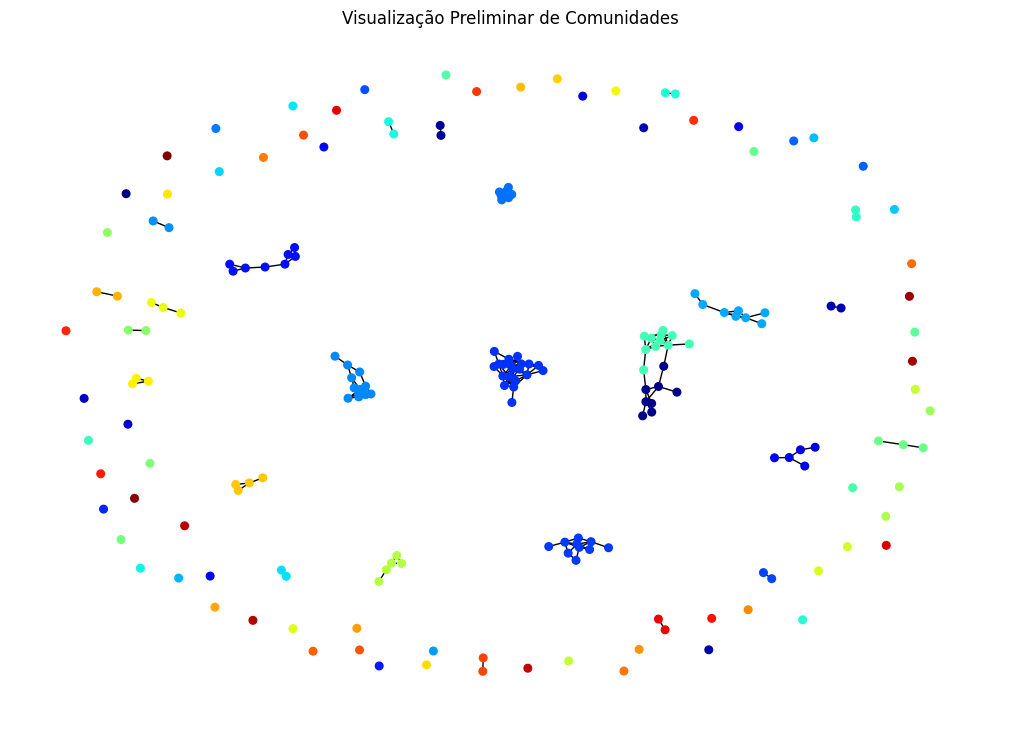

In [70]:

# Verificação visual -> Plot Rápido
plt.figure(figsize=(10, 7))
nx.draw(G, node_size=30, node_color=list(particao.values()), cmap=plt.cm.jet)
plt.title("Visualização Preliminar de Comunidades")
plt.show()